Name: Kushagra Raghuvanshi

Registration Number: 23BSA10072

Application Number: IN26011064

Batch Number: 2B

In [15]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import os

# The error message indicates that the dataset files are available at this path.
# We will use this to directly load the CSV.
dataset_base_path = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset"
subdirectory = "csv"
file_name = "mass_case_description_train_set.csv"

# Construct the full path to the CSV file, including the 'csv' subdirectory
full_file_path = os.path.join(dataset_base_path, subdirectory, file_name)

# Load the CSV file using pandas
df = pd.read_csv(full_file_path)

print("First 5 records:")
display(df.head())

First 5 records:


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


--- MODEL EVALUATION METRICS ---
Accuracy:  82.72%
Recall:    81.25%
F1-Score:  83.20%

--- DETAILED CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

Malignant (0)       0.85      0.81      0.83       128
   Benign (1)       0.80      0.84      0.82       115

     accuracy                           0.83       243
    macro avg       0.83      0.83      0.83       243
 weighted avg       0.83      0.83      0.83       243



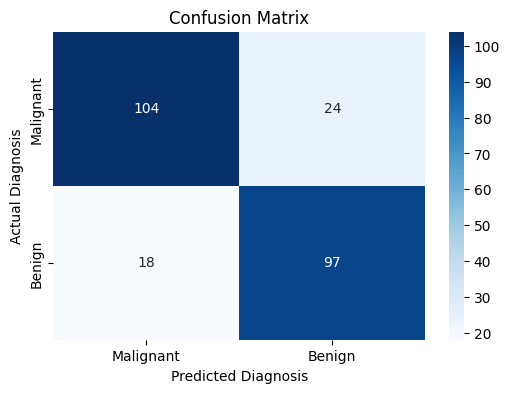

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

# 2. Prepare the Dataset from the loaded CSV (df)
# The 'pathology' column will be our target variable (y).
# We'll map 'MALIGNANT' to 0 and 'BENIGN' to 1 to match the original example's interpretation of pos_label=0 for Malignant.
# Ensure 'df' is available from the previous cell.

# Make a copy to avoid SettingWithCopyWarning
data_for_model = df.copy()

# Map 'pathology' to numerical values
# 0 = Malignant, 1 = Benign
data_for_model['pathology_encoded'] = data_for_model['pathology'].map({'MALIGNANT': 0, 'BENIGN': 1})

# Drop rows where 'pathology_encoded' is NaN
# This handles cases where 'pathology' column might contain values other than 'MALIGNANT' or 'BENIGN'
data_for_model.dropna(subset=['pathology_encoded'], inplace=True)

# Convert 'pathology_encoded' to integer type after dropping NaNs
data_for_model['pathology_encoded'] = data_for_model['pathology_encoded'].astype(int)

# Define target variable
y = data_for_model['pathology_encoded']

# Define features (X)
# Drop identifier and path columns, and the original 'pathology' column
features_to_drop = [
    'patient_id', 'abnormality id', 'pathology',
    'image file path', 'cropped image file path', 'ROI mask file path',
    'pathology_encoded' # <<< FIX: Explicitly drop the target variable from features to avoid data leakage
]

X_raw = data_for_model.drop(columns=features_to_drop)

# Handle categorical features using one-hot encoding
categorical_cols = [
    'breast_density', 'left or right breast', 'image view',
    'abnormality type', 'mass shape', 'mass margins'
]

# Convert 'breast_density' to string to treat it as nominal categorical for one-hot encoding
X_raw['breast_density'] = X_raw['breast_density'].astype(str)

X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

# --- NEW: Robust NaN handling for features ---
# Drop any columns in X that are entirely NaN (e.g., if a dummy variable column ends up with all False/NaNs after filtering)
X = X.dropna(axis=1, how='all')

# Fill any remaining NaN values in X with the column mean (for numerical features)
X = X.fillna(X.mean())

# 3. Split the Data
# We use 80% of the data to train the model, and hold back 20% to test it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scale the Features
# Scaling puts everything on the same playing field.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Build and Train the Model
# Logistic Regression is an excellent baseline model for binary classification (Malignant vs. Benign).
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' often good for small datasets
model.fit(X_train_scaled, y_train)

# 6. Make Predictions on the Test Data
y_pred = model.predict(X_test_scaled)

# ---------------------------------------------------------
# 7. CALCULATE METRICS (Accuracy, Recall, F1-Score)
# ---------------------------------------------------------

# Note: Since 0 is 'Malignant', we set pos_label=0 to calculate these metrics specifically for the cancer detection rate.
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)

print("--- MODEL EVALUATION METRICS ---")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%\n")

print("--- DETAILED CLASSIFICATION REPORT ---")
# This built-in function gives you a complete breakdown of all metrics for both classes
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))

# 8. Visualizing the Results (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.show()

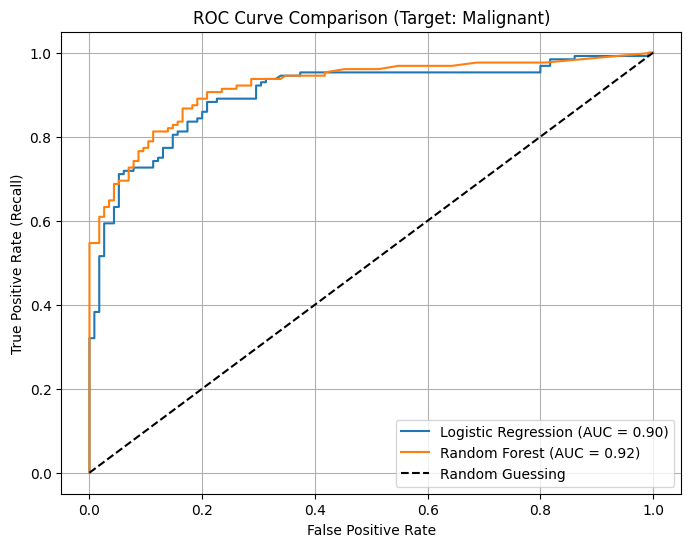

------------------------------
-- Metrics with Custom Safety Threshold (0.3) ---
New Recall (Malignant, class 0): 86.72%
New Precision (Malignant, class 0): 82.22%
New F1-Score (Malignant, class 0): 84.41%
------------------------------


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# 1. Initialize multiple models
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Get predicted probabilities instead of hard labels (needed for ROC and custom thresholds)
# predict_proba returns [prob_of_0, prob_of_1]. Class 0 is Malignant.
y_prob_lr = model.predict_proba(X_test_scaled)[:, 0] # Probability of class 0 (Malignant)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 0] # Probability of class 0 (Malignant)

# 3. Calculate ROC Curve details
# pos_label=0 correctly tracks the malignant class (class 0)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr, pos_label=0)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf, pos_label=0)

# Corrected AUC calculation: roc_auc_score expects the positive class to be '1'.
# Since our 'Malignant' class is '0', we invert y_test for the AUC calculation.
auc_lr = roc_auc_score(1 - y_test, y_prob_lr)
auc_rf = roc_auc_score(1 - y_test, y_prob_rf)

# 4. Plot the ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison (Target: Malignant)')
plt.legend()
plt.grid(True)
plt.show()

# 5. Example of applying a custom safer threshold (e.g., 0.3 instead of 0.5)
# If probability of cancer (class 0) is > 30%, classify as cancer (0)
custom_threshold = 0.3
y_pred_custom = [0 if prob >= custom_threshold else 1 for prob in y_prob_lr]

print("---" * 10)
print("-- Metrics with Custom Safety Threshold (0.3) ---")
print(f"New Recall (Malignant, class 0): {recall_score(y_test, y_pred_custom, pos_label=0)*100:.2f}%")
print(f"New Precision (Malignant, class 0): {precision_score(y_test, y_pred_custom, pos_label=0)*100:.2f}%")
print(f"New F1-Score (Malignant, class 0): {f1_score(y_test, y_pred_custom, pos_label=0)*100:.2f}%")
print("---" * 10)